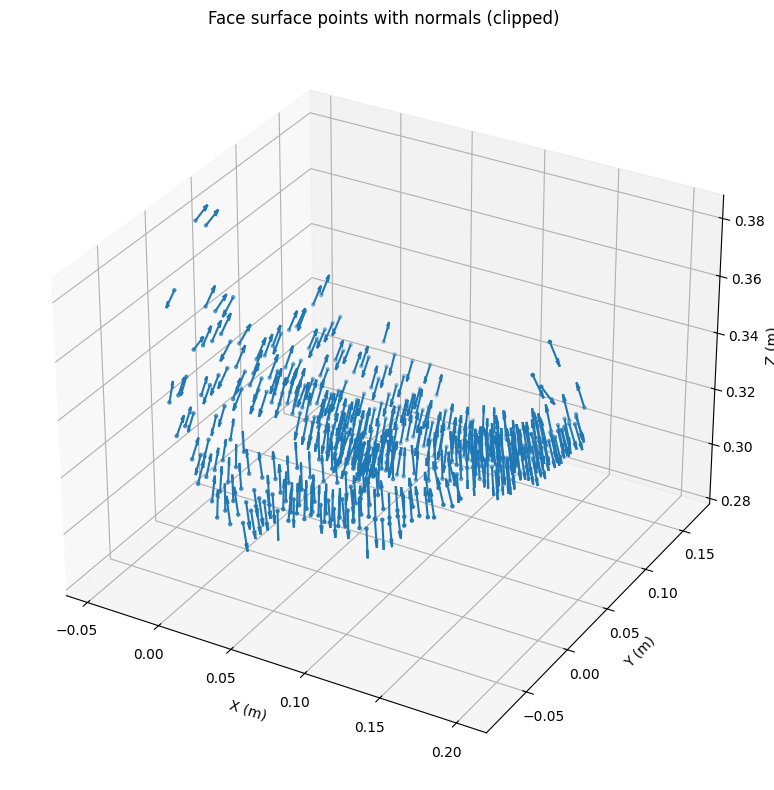

In [4]:
import json
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa

with open("scan_points_with_normals.json", "r", encoding="utf-8") as f:
    data = json.load(f)

P = np.array([[d["X_m"], d["Y_m"], d["Z_m"]] for d in data], dtype=float)
N = np.array([[d["nx"], d["ny"], d["nz"]] for d in data], dtype=float)

X, Y, Z  = P[:, 0], P[:, 1], P[:, 2]
NX, NY, NZ = N[:, 0], N[:, 1], N[:, 2]

# 🔹 Z 범위로 outlier 제거 (예: 0.2m ~ 0.6m 사이만 사용)
mask = (Z > 0.2) & (Z < 0.6)
X, Y, Z  = X[mask], Y[mask], Z[mask]
NX, NY, NZ = NX[mask], NY[mask], NZ[mask]

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(X, Y, Z, s=5)

scale = 0.01
ax.quiver(X, Y, Z, NX, NY, NZ, length=scale, normalize=True)

ax.set_xlabel("X (m)")
ax.set_ylabel("Y (m)")
ax.set_zlabel("Z (m)")
ax.set_title("Face surface points with normals (clipped)")

plt.tight_layout()
plt.show()


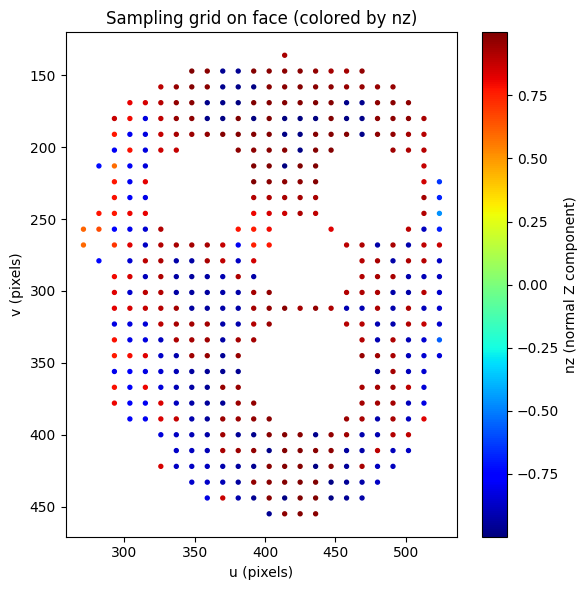

In [2]:
import json
import numpy as np
import matplotlib.pyplot as plt

with open("scan_points_with_normals.json", "r", encoding="utf-8") as f:
    data = json.load(f)

u = np.array([d["u"] for d in data])
v = np.array([d["v"] for d in data])
nz = np.array([d["nz"] for d in data], dtype=float)

plt.figure(figsize=(6, 6))
sc = plt.scatter(u, v, c=nz, s=8, cmap="jet")  # nz에 따라 색깔
plt.gca().invert_yaxis()  # 이미지 좌표계와 맞추기 위해 y축 뒤집기
plt.colorbar(sc, label="nz (normal Z component)")
plt.title("Sampling grid on face (colored by nz)")
plt.xlabel("u (pixels)")
plt.ylabel("v (pixels)")
plt.tight_layout()
plt.show()
